In [1]:
!pip -q install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.1 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="QThjfB4sjPBDi1eJfvsF")
project = rf.workspace("computervision-lhxm8").project("road-damage-semantic")
version = project.version(1)
dataset = version.download("png-mask-semantic")

dataset.location


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-damage---Semantic-1 in png-mask-semantic:: 100%|██████████| 308/308 [00:00<00:00, 2331.08it/s]


'/content/road-damage---Semantic-1'

In [3]:
import os
from pathlib import Path

root = Path(dataset.location)

def find_split_dir(root: Path, split_name: str):
    candidates = [
        root / split_name,
        root / split_name.capitalize(),
        root / split_name.upper(),
        root / {"valid":"valid", "val":"valid", "train":"train", "test":"test"}.get(split_name, split_name),
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == split_name:
            return p
    return None

train_dir = find_split_dir(root, "train")
valid_dir = find_split_dir(root, "valid") or find_split_dir(root, "val")
test_dir  = find_split_dir(root, "test")

train_dir, valid_dir, test_dir


(PosixPath('/content/road-damage---Semantic-1/train'),
 PosixPath('/content/road-damage---Semantic-1/valid'),
 PosixPath('/content/road-damage---Semantic-1/test'))

In [4]:
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images_and_masks(split_dir: Path):
    if split_dir is None:
        return []

    all_files = list(split_dir.rglob("*"))
    imgs = [p for p in all_files if p.suffix.lower() in IMG_EXTS]
    masks = [p for p in all_files if p.suffix.lower() == ".png" and ("mask" in p.stem.lower() or "masks" in str(p).lower())]

    def is_probably_mask(p: Path):
        s = str(p).lower()
        return ("mask" in p.stem.lower()) or ("/masks" in s) or ("_mask" in p.stem.lower())

    imgs = [p for p in imgs if not is_probably_mask(p)]
    masks = [p for p in masks if p.exists()]

    masks_by_stem = {m.stem.replace("_mask", "").replace("mask_", ""): m for m in masks}

    pairs = []
    for img in imgs:
        key = img.stem
        m = masks_by_stem.get(key)
        if m is None:
            m2 = img.parent / (img.stem + "_mask.png")
            if m2.exists():
                m = m2
        if m is None:
            m3 = img.parent / (img.stem + "_mask" + img.suffix)
            if m3.exists():
                m = m3
        if m is None:
            for cand in split_dir.rglob("**/masks/*.png"):
                if cand.stem == key:
                    m = cand
                    break
        if m is not None and m.exists():
            pairs.append((img, m))

    pairs = sorted(pairs, key=lambda x: str(x[0]))
    return pairs

train_pairs = list_images_and_masks(train_dir)
valid_pairs = list_images_and_masks(valid_dir) if valid_dir else []
test_pairs  = list_images_and_masks(test_dir) if test_dir else []

len(train_pairs), len(valid_pairs), len(test_pairs), (train_pairs[0] if train_pairs else None)


(50,
 50,
 50,
 (PosixPath('/content/road-damage---Semantic-1/train/1007607_RS_386_386RS289112_28960_RAW_jpg.rf.6175f45ccb70be6295de8a3c79af5970.jpg'),
  PosixPath('/content/road-damage---Semantic-1/train/1007607_RS_386_386RS289112_28960_RAW_jpg.rf.6175f45ccb70be6295de8a3c79af5970_mask.png')))

In [5]:
import numpy as np
from PIL import Image
from tqdm import tqdm

def load_mask_raw(mask_path: Path):
    m = Image.open(mask_path)
    arr = np.array(m)
    return arr

sample_mask = load_mask_raw(train_pairs[0][1])
sample_mask.shape, sample_mask.dtype


((640, 640), dtype('uint8'))

In [6]:
def is_rgb_mask(arr: np.ndarray):
    return arr.ndim == 3 and arr.shape[2] >= 3

def is_single_channel_mask(arr: np.ndarray):
    return arr.ndim == 2 or (arr.ndim == 3 and arr.shape[2] == 1)

rgb_mode = is_rgb_mask(sample_mask)

color2id = None

if rgb_mode:
    unique_colors = set()
    for _, mpath in tqdm(train_pairs, desc="Escaneando colores (train)"):
        arr = load_mask_raw(mpath)
        arr = arr[:, :, :3]
        colors = np.unique(arr.reshape(-1, 3), axis=0)
        for c in colors:
            unique_colors.add(tuple(int(x) for x in c))
    unique_colors = sorted(list(unique_colors))
    color2id = {c:i for i, c in enumerate(unique_colors)}
    num_classes = len(unique_colors)
else:
    ids = set()
    for _, mpath in tqdm(train_pairs, desc="Escaneando IDs (train)"):
        arr = load_mask_raw(mpath)
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        ids.update(np.unique(arr).tolist())
    ids = sorted(list(set(int(x) for x in ids)))
    num_classes = (max(ids) + 1) if len(ids) > 0 else 1

rgb_mode, num_classes


Escaneando IDs (train): 100%|██████████| 50/50 [00:02<00:00, 18.38it/s]


(False, 4)

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

class SegDataset(Dataset):
    def __init__(self, pairs, img_size=512, rgb_mode=False, color2id=None):
        self.pairs = pairs
        self.img_size = img_size
        self.rgb_mode = rgb_mode
        self.color2id = color2id

    def __len__(self):
        return len(self.pairs)

    def _mask_to_ids(self, mask_arr):
        if not self.rgb_mode:
            if mask_arr.ndim == 3:
                mask_arr = mask_arr[:, :, 0]
            return mask_arr.astype(np.int64)

        mask_arr = mask_arr[:, :, :3]
        h, w, _ = mask_arr.shape
        flat = mask_arr.reshape(-1, 3)
        ids = np.zeros((flat.shape[0],), dtype=np.int64)
        for color, idx in self.color2id.items():
            c = np.array(color, dtype=np.uint8)
            match = np.all(flat == c, axis=1)
            ids[match] = idx
        return ids.reshape(h, w)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask_arr = np.array(Image.open(mask_path))

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        if mask_arr.ndim == 2:
            mask_arr = cv2.resize(mask_arr, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        else:
            mask_arr = cv2.resize(mask_arr, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        mask_ids = self._mask_to_ids(mask_arr)

        img_t = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        mask_t = torch.from_numpy(mask_ids).long()

        return img_t, mask_t

img_size = 512
batch_size = 8

train_ds = SegDataset(train_pairs, img_size=img_size, rgb_mode=rgb_mode, color2id=color2id)
valid_ds = SegDataset(valid_pairs, img_size=img_size, rgb_mode=rgb_mode, color2id=color2id) if len(valid_pairs) else None

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True) if valid_ds else None

len(train_loader), (len(valid_loader) if valid_loader else None)


(7, 7)

In [9]:
model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [19]:
import torch
import torchvision
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, momentum=0)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))




`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.


In [20]:
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def compute_miou(logits, targets, num_classes):
    preds = torch.argmax(logits, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_c = (preds == cls)
        targ_c = (targets == cls)
        inter = (pred_c & targ_c).sum().item()
        union = (pred_c | targ_c).sum().item()
        if union == 0:
            continue
        ious.append(inter / union)
    return float(np.mean(ious)) if len(ious) else 0.0

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            out = model(imgs)["out"]
            loss = criterion(out, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0.0
    total_miou = 0.0
    for imgs, masks in tqdm(loader, desc="Valid", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        out = model(imgs)["out"]
        loss = criterion(out, masks)
        miou = compute_miou(out, masks, num_classes)

        total_loss += loss.item() * imgs.size(0)
        total_miou += miou * imgs.size(0)

    return total_loss / len(loader.dataset), total_miou / len(loader.dataset)


In [21]:
import os

epochs = 25
best_miou = -1.0
save_path = "best_deeplabv3_semantic.pth"

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader)

    if valid_loader:
        val_loss, val_miou = validate(model, valid_loader)
        print(f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_mIoU={val_miou:.4f}")
        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(
                {
                    "model": model.state_dict(),
                    "num_classes": num_classes,
                    "img_size": img_size,
                    "rgb_mode": rgb_mode,
                    "color2id": color2id,
                },
                save_path,
            )
    else:
        print(f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f}")
        torch.save(
            {
                "model": model.state_dict(),
                "num_classes": num_classes,
                "img_size": img_size,
                "rgb_mode": rgb_mode,
                "color2id": color2id,
            },
            save_path,
        )

print("Guardado:", save_path)


Train:   0%|          | 0/7 [00:00<?, ?it/s]`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 1/25 | train_loss=1.4563 | val_loss=1.2287 | val_mIoU=0.1514


Epoch 2/25 | train_loss=1.4291 | val_loss=1.2222 | val_mIoU=0.1699


Epoch 3/25 | train_loss=1.4037 | val_loss=1.2075 | val_mIoU=0.1652


Epoch 4/25 | train_loss=1.3758 | val_loss=1.2328 | val_mIoU=0.1476


...

Epoch 21/25 | train_loss=1.0137 | val_loss=0.9878 | val_mIoU=0.2302


Epoch 22/25 | train_loss=0.9942 | val_loss=0.9634 | val_mIoU=0.2340


Epoch 23/25 | train_loss=0.9787 | val_loss=0.9521 | val_mIoU=0.2476


Epoch 24/25 | train_loss=0.9637 | val_loss=0.9349 | val_mIoU=0.2487


Epoch 25/25 | train_loss=0.9473 | val_loss=0.9242 | val_mIoU=0.2495
Guardado: best_deeplabv3_semantic.pth


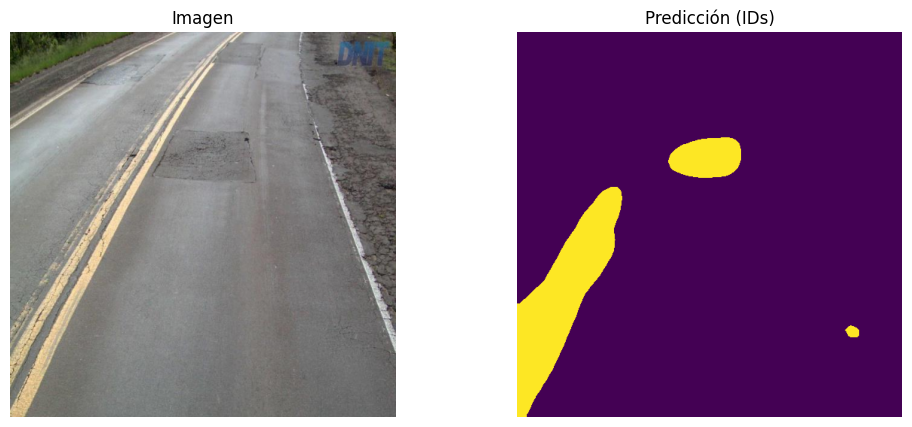

In [18]:
import matplotlib.pyplot as plt
import numpy as np

ckpt = torch.load(save_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

def predict_one(img_path: str, img_size=512):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)

    x = torch.from_numpy(img_res).float().permute(2, 0, 1) / 255.0
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(x)["out"]
        pred = torch.argmax(out, dim=1).squeeze(0).detach().cpu().numpy().astype(np.uint8)

    return img_res, pred

sample_img = str(train_pairs[45][0])
img_res, pred = predict_one(sample_img, img_size=img_size)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_res)
plt.axis("off")
plt.title("Imagen")

plt.subplot(1, 2, 2)
plt.imshow(pred)
plt.axis("off")
plt.title("Predicción (IDs)")
plt.show()
